In this notebook Seamese network model for handwriting author verification with triplet loss trained. As backbone vit_base_patch16_384 used with freezed parameters.

In [1]:
!pip install -q gdown

file_id = "1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi"
output_name = "all_data_2.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi
From (redirected): https://drive.google.com/uc?id=1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi&confirm=t&uuid=c0936a0f-1bb3-472f-91ef-939d2f44c0f0
To: /kaggle/working/all_data_2.zip
100%|███████████████████████████████████████| 1.71G/1.71G [00:13<00:00, 123MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_2.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_2', 'all_data_2.zip', '.virtual_documents']

In [3]:
!pip install torchvision

In [4]:
!pip install timm

In [5]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import timm


In [6]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


In [7]:
DATA_ROOT = "/kaggle/working/all_data_2"

Let's create class of our dataset. The dataset is a combination of IAM and Cedar datasets.
The documents in IAM dataset are patched into lines. The CEDAR datset is used without changes.
The dataset creates triplets of images:
from IAM dataset, for positive example taken image of the same author, for negative - image of other author;
from CEDAR dataset, for positive example taken image of signature of the same author, for negative - image of forgery of signature of this author.
The dataset allows to control the ratio of data from CEDAR and IAM datasets, as default the ratio is 50/50.
The triplets are created 'on the fly'.

In [12]:
class TripletDataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 min_height=50, max_height=500, authors_list=None,
                 cedar_ratio=0.5):
        """
        Dataset for Triplet Loss with multiple data sources (IAM and CEDAR).

        Args:
            root: Root directory containing 'iam' and 'cedar' folders
            transform: Image transformations
            size: Number of triplets per epoch
            min_height: Minimum image height filter
            max_height: Maximum image height filter
            authors_list: List of author IDs to include (for train/val split)
            cedar_ratio: Probability of sampling triplet from CEDAR (0.5 = 50%)
        """
        self.transform = transform
        self.size = size
        self.min_height = min_height
        self.max_height = max_height
        self.cedar_ratio = cedar_ratio

        # Separate data structures for IAM and CEDAR
        self.iam_data = {}      # author_id -> list of image paths (IAM)
        self.cedar_original = {} # author_id -> list of original signatures
        self.cedar_forgery = {}  # author_id -> list of forgery signatures

        # Scan IAM folder (handwriting lines)
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            height = img.size[1]
                        if self.min_height <= height <= self.max_height:
                            valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        # Scan CEDAR folder (signatures)
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            # Scan original signatures
            original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(original_path):
                for folder in os.listdir(original_path):
                    author_path = os.path.join(original_path, folder)
                    if not os.path.isdir(author_path):
                        continue

                    author_id = folder
                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            continue

                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                height = img.size[1]
                            if self.min_height <= height <= self.max_height:
                                valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            # Scan forgery signatures
            forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(forgery_path):
                for folder in os.listdir(forgery_path):
                    author_path = os.path.join(forgery_path, folder)
                    if not os.path.isdir(author_path):
                        continue

                    author_id = folder
                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            continue

                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                height = img.size[1]
                            if self.min_height <= height <= self.max_height:
                                valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        # Filter authors based on authors_list (if provided)
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}

        # Build lists of authors with sufficient data
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.cedar_authors = [a for a in self.cedar_original.keys() if len(self.cedar_original.get(a, [])) >= 2]

        # For CEDAR, authors need at least one forgery for negative sampling
        self.cedar_authors_with_forgery = [a for a in self.cedar_authors if a in self.cedar_forgery and self.cedar_forgery[a]]

        # All authors for negative sampling (any author with at least 1 image)
        self.iam_all_authors = list(self.iam_data.keys())
        self.cedar_all_authors = list(self.cedar_original.keys())



    def __len__(self):
        return self.size

    def _get_iam_triplet(self):
        """Create triplet from IAM dataset (handwriting lines)."""
        # Anchor and Positive: same author
        author = random.choice(self.iam_authors)
        images = self.iam_data[author]
        anchor_path, positive_path = random.sample(images, 2)

        # Negative: different author
        if len(self.iam_all_authors) < 2:
            negative_author = author
            negative_images = [p for p in images if p != anchor_path and p != positive_path]
            if not negative_images:
                negative_images = images
            negative_path = random.choice(negative_images)
        else:
            negative_author = random.choice(self.iam_all_authors)
            while negative_author == author:
                negative_author = random.choice(self.iam_all_authors)
            negative_path = random.choice(self.iam_data[negative_author])

        return anchor_path, positive_path, negative_path

    def _get_cedar_triplet(self):
        """
        Create triplet from CEDAR dataset.
        Anchor and Positive: two different original signatures from same author.
        Negative: forgery signature of the SAME author.
        """
        # Anchor and Positive: same author, two different original signatures
        author = random.choice(self.cedar_authors_with_forgery)
        original_images = self.cedar_original[author]
        anchor_path, positive_path = random.sample(original_images, 2)

        # Negative: forgery of the SAME author
        forgery_images = self.cedar_forgery[author]
        negative_path = random.choice(forgery_images)

        return anchor_path, positive_path, negative_path

    def __getitem__(self, idx):
        # Decide which dataset to sample from based on cedar_ratio
        use_cedar = random.random() < self.cedar_ratio

        if use_cedar and self.cedar_authors_with_forgery:
            anchor_path, positive_path, negative_path = self._get_cedar_triplet()
        else:
            # Fallback to IAM if CEDAR not available
            anchor_path, positive_path, negative_path = self._get_iam_triplet()

        # Load images
        anchor = Image.open(anchor_path).convert('L')
        positive = Image.open(positive_path).convert('L')
        negative = Image.open(negative_path).convert('L')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

Separating the authors into train and validation

In [15]:
iam_path = os.path.join(DATA_ROOT, 'iam')
cedar_path = os.path.join(DATA_ROOT, 'cedar', 'original')

iam_authors = os.listdir(iam_path) if os.path.exists(iam_path) else []
cedar_authors = os.listdir(cedar_path) if os.path.exists(cedar_path) else []

all_authors = list(set(iam_authors + cedar_authors))
print(f"IAM authors: {len(iam_authors)}")
print(f"CEDAR authors: {len(cedar_authors)}")
print(f"Total unique authors: {len(all_authors)}")

random.shuffle(all_authors)
split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}")
print(f"Val authors: {len(val_authors)}")

IAM authors: 657
CEDAR authors: 55
Total unique authors: 657
Train authors: 525
Val authors: 132


Creating tranformations, datasets and dataloaders. Since we will use the model which takes 384*384 images, we resize all images into 384*384

In [16]:
train_transform_all_data_384 = T.Compose([
    T.Resize((384, 384)), 
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform_all_data_384 = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [18]:
#create dataset
train_dataset_all_384 = TripletDataset(
    root=DATA_ROOT,
    transform=train_transform_all_data_384,
    size=5000,
    min_height=50,
    max_height=500,
    authors_list=train_authors,
    cedar_ratio=0.5
)

val_dataset_all_384 = TripletDataset(
    root=DATA_ROOT,
    transform=val_transform_all_data_384,
    size=2000,
    min_height=50,
    max_height=500,
    authors_list=val_authors,
    cedar_ratio=0.5
)

# Create dataloaders
train_loader_all_384 = DataLoader(
    train_dataset_all_384,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_all_384 = DataLoader(
    val_dataset_all_384,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


Let's look at an example of our data

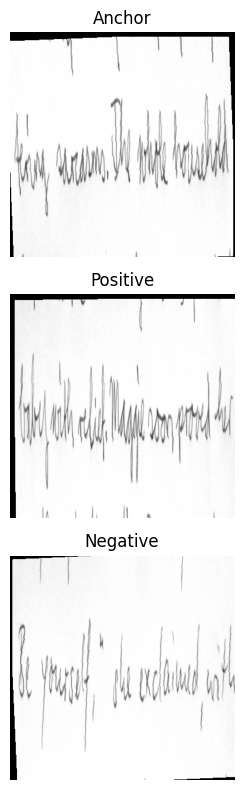

In [20]:
anchor, positive, negative= train_dataset_all_384[0]

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.imshow(anchor[0], cmap='gray')
plt.title(f"Anchor")
plt.axis('off')

plt.subplot(3, 1, 2)
plt.imshow(positive[0], cmap='gray')
plt.title("Positive")
plt.axis('off')

plt.subplot(3, 1, 3)
plt.imshow(negative[0], cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.tight_layout()
plt.show()

Now let's create class of our model. The model uses triplet loss and vit_base_patch16_384 model. The class allows to use 'aggressive' mode for freezing layers, namely freeze all layers except for 2 last. If the mode is not 'aggressive', all layers are trained 

In [ ]:
class TripletNetwork(nn.Module):
    def __init__(self, embedding_size=256, model_name='vit_base_patch16_224',
                 pretrained=True, freeze_mode="aggressive"):
        super(TripletNetwork, self).__init__()

        # Load ViT
        self.vit = timm.create_model(model_name, pretrained=pretrained)

        # Adapt first layer for 1 channel
        old_conv = self.vit.patch_embed.proj
        new_conv = nn.Conv2d(1, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride,
                             padding=old_conv.padding,
                             bias=False)
        with torch.no_grad():
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        self.vit.patch_embed.proj = new_conv

        # Remove classifier head
        if hasattr(self.vit, 'head'):
            in_features = self.vit.head.in_features
            self.vit.head = nn.Identity()
        else:
            in_features = self.vit.num_features

        # Freeze layers (optional)
        if freeze_mode == "aggressive":
            for param in self.vit.parameters():
                param.requires_grad = False
            # Unfreeze last blocks
            for i, block in enumerate(self.vit.blocks):
                if i >= len(self.vit.blocks) - 2:
                    for param in block.parameters():
                        param.requires_grad = True
            for param in self.vit.norm.parameters():
                param.requires_grad = True
            for param in self.vit.patch_embed.proj.parameters():
                param.requires_grad = True

        # Embedding head (projects features to embedding space)
        self.embedding = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        self.embedding_size = embedding_size

        # Statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.vit(x)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)  # L2 normalize for stable training

    def forward(self, anchor, positive, negative):
        # Getting embeddings for all three input images
        emb_anchor = self.forward_one(anchor)
        emb_positive = self.forward_one(positive)
        emb_negative = self.forward_one(negative)

        return emb_anchor, emb_positive, emb_negative

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import numpy as np

def train_triplet_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    margin=1.0,
    device=None,
    save_path='best_triplet_model.pth',
    weight_decay=0.01,
    warmup_epochs=5
):
    """
    Training function for Triplet Network with Vision Transformer backbone.
    Uses Warmup + Cosine Annealing learning rate schedule.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    # Create optimizer with target learning rate
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Warmup scheduler: linear increase from 0 to lr
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=0.01,  # start from 1% of target lr
        end_factor=1.0,
        total_iters=warmup_epochs
    )

    # Cosine annealing scheduler: decay from lr to 1e-6
    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs - warmup_epochs,
        eta_min=1e-6
    )

    # Combine schedulers: warmup first, then cosine annealing
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )

    # Triplet loss
    triplet_loss = nn.TripletMarginLoss(margin=margin, p=2)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_triplet_accuracy': [], 'val_triplet_accuracy': [],
        'val_roc_auc': [], 'val_best_accuracy': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_triplet_correct = 0
        train_triplet_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            # Forward pass
            emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

            # Compute triplet loss
            loss = triplet_loss(emb_anchor, emb_positive, emb_negative)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Compute triplet accuracy
            dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
            dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
            train_triplet_correct += (dist_pos < dist_neg).sum().item()
            train_triplet_total += len(dist_pos)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss_avg = train_loss / len(train_loader)
        train_triplet_acc = train_triplet_correct / train_triplet_total

        #evaluating
        model.eval()
        val_loss = 0.0
        val_triplet_correct = 0
        val_triplet_total = 0
        val_distances_pos = []
        val_distances_neg = []

        with torch.no_grad():
            for anchor, positive, negative in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

                loss = triplet_loss(emb_anchor, emb_positive, emb_negative)
                val_loss += loss.item()

                dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
                dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
                val_triplet_correct += (dist_pos < dist_neg).sum().item()
                val_triplet_total += len(dist_pos)

                val_distances_pos.extend(dist_pos.cpu().numpy())
                val_distances_neg.extend(dist_neg.cpu().numpy())

        val_loss_avg = val_loss / len(val_loader)
        val_triplet_acc = val_triplet_correct / val_triplet_total

        # Compute ROC-AUC and best accuracy
        all_distances = val_distances_pos + val_distances_neg
        all_labels = [1] * len(val_distances_pos) + [0] * len(val_distances_neg)
        val_roc_auc = roc_auc_score(all_labels, [-d for d in all_distances])

        # Find best accuracy with optimal threshold
        best_acc = 0
        best_threshold = 0
        unique_distances = np.unique(all_distances)
        for threshold in unique_distances:
            pred = (np.array(all_distances) <= threshold).astype(int)
            acc = (pred == np.array(all_labels)).mean()
            if acc > best_acc:
                best_acc = acc
                best_threshold = threshold

        # Update scheduler (step after each epoch)
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_triplet_accuracy'].append(train_triplet_acc)
        history['val_triplet_accuracy'].append(val_triplet_acc)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_best_accuracy'].append(best_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Triplet Acc: {train_triplet_acc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Triplet Acc: {val_triplet_acc:.4f}")
        print(f"  Val ROC-AUC: {val_roc_auc:.4f}, Best Val Accuracy: {best_acc:.4f} (threshold={best_threshold:.3f})")
        print(f"  Distances - Positive: {np.mean(val_distances_pos):.3f}, Negative: {np.mean(val_distances_neg):.3f}")
        print(f"  LR: {current_lr:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_best_accuracy': best_acc,
                'val_triplet_accuracy': val_triplet_acc
            }, save_path)
            print(f"Model saved! ROC-AUC: {val_roc_auc:.4f}, Best Acc: {best_acc:.4f}")

    return history

Launching training

In [ ]:
model_all_dataset_384 = TripletNetwork(
    embedding_size=256,
    model_name='vit_base_patch16_384',
    pretrained=True,
    freeze_mode="aggressive"
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_384 = train_triplet_model(
    model=model_all_dataset_384,
    train_loader=train_loader_all_384,
    val_loader=val_loader_all_384,
    epochs=30,
    lr=0.0001,
    margin=1.0,
    device=device,
    save_path='best_triplet_model_all_dataset_384.pth',
    weight_decay=0.001,
    warmup_epochs=5)


model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

Total parameters: 86,746,368
Trainable parameters: 15,423,744 (17.8%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [04:26<00:00,  1.07s/it]



Epoch 1/30
  Train Loss: 0.9740, Triplet Acc: 0.6092
  Val Loss:   0.7418, Triplet Acc: 0.9085
  Val ROC-AUC: 0.8741, Best Val Accuracy: 0.8160 (threshold=0.446)
  Distances - Positive: 0.350, Negative: 0.608
  LR: 0.000021
Model saved! ROC-AUC: 0.8741, Best Acc: 0.8160


Epoch 2/30 [Val]: 100%|██████████| 250/250 [04:27<00:00,  1.07s/it]


...

Epoch 24/30 [Val]: 100%|██████████| 250/250 [04:25<00:00,  1.06s/it]



Epoch 24/30
  Train Loss: 0.1158, Triplet Acc: 0.9756
  Val Loss:   0.1015, Triplet Acc: 0.9870
  Val ROC-AUC: 0.9887, Best Val Accuracy: 0.9590 (threshold=0.712)
  Distances - Positive: 0.232, Negative: 1.579
  LR: 0.000014
Model saved! ROC-AUC: 0.9887, Best Acc: 0.9590


Epoch 25/30 [Val]: 100%|██████████| 250/250 [04:25<00:00,  1.06s/it]



Epoch 25/30
  Train Loss: 0.1114, Triplet Acc: 0.9818
  Val Loss:   0.1104, Triplet Acc: 0.9810
  Val ROC-AUC: 0.9847, Best Val Accuracy: 0.9517 (threshold=0.695)
  Distances - Positive: 0.230, Negative: 1.547
  LR: 0.000010


Epoch 26/30 [Train]:  54%|█████▍    | 338/625 [12:33<10:42,  2.24s/it, loss=0.2950]

The model achieved best quality at 24th epoch with ROC-AUC: 0.9887, Best Acc: 0.9590, the model saved, let's vizualize results

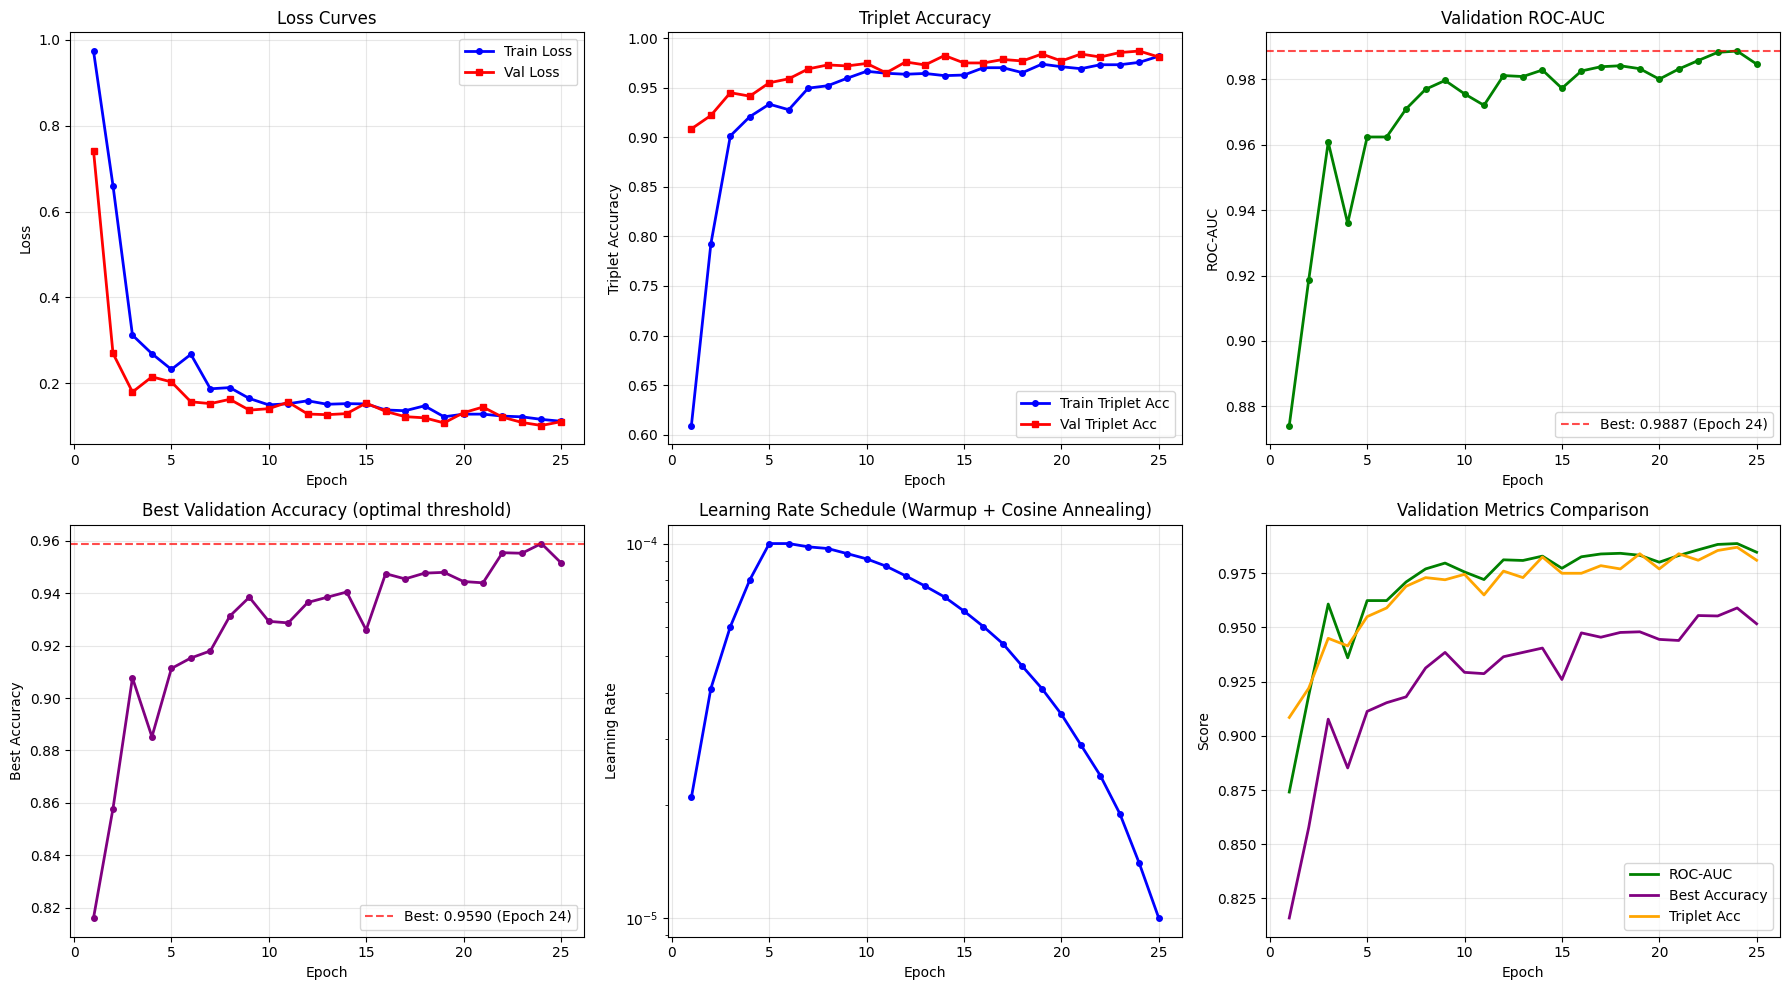

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from logs
epochs = list(range(1, 26))

train_loss = [
    0.9740, 0.6604, 0.3120, 0.2688, 0.2322,
    0.2673, 0.1870, 0.1898, 0.1645, 0.1495,
    0.1522, 0.1591, 0.1510, 0.1524, 0.1518,
    0.1377, 0.1359, 0.1473, 0.1218, 0.1279,
    0.1280, 0.1234, 0.1217, 0.1158, 0.1114
]

val_loss = [
    0.7418, 0.2696, 0.1795, 0.2149, 0.2030,
    0.1567, 0.1525, 0.1625, 0.1373, 0.1407,
    0.1559, 0.1282, 0.1267, 0.1292, 0.1538,
    0.1344, 0.1221, 0.1194, 0.1075, 0.1313,
    0.1445, 0.1210, 0.1086, 0.1015, 0.1104
]

train_triplet_acc = [
    0.6092, 0.7924, 0.9014, 0.9208, 0.9334,
    0.9278, 0.9496, 0.9520, 0.9596, 0.9666,
    0.9646, 0.9636, 0.9644, 0.9622, 0.9628,
    0.9702, 0.9702, 0.9652, 0.9738, 0.9712,
    0.9692, 0.9732, 0.9732, 0.9756, 0.9818
]

val_triplet_acc = [
    0.9085, 0.9220, 0.9450, 0.9415, 0.9550,
    0.9590, 0.9690, 0.9730, 0.9720, 0.9745,
    0.9650, 0.9760, 0.9730, 0.9825, 0.9750,
    0.9750, 0.9785, 0.9770, 0.9840, 0.9770,
    0.9840, 0.9810, 0.9855, 0.9870, 0.9810
]

val_roc_auc = [
    0.8741, 0.9187, 0.9608, 0.9360, 0.9624,
    0.9624, 0.9710, 0.9770, 0.9797, 0.9756,
    0.9721, 0.9812, 0.9809, 0.9829, 0.9773,
    0.9826, 0.9839, 0.9842, 0.9833, 0.9801,
    0.9832, 0.9858, 0.9883, 0.9887, 0.9847
]

val_best_acc = [
    0.8160, 0.8578, 0.9077, 0.8852, 0.9113,
    0.9153, 0.9180, 0.9313, 0.9385, 0.9293,
    0.9287, 0.9365, 0.9385, 0.9405, 0.9260,
    0.9475, 0.9455, 0.9477, 0.9480, 0.9445,
    0.9440, 0.9555, 0.9553, 0.9590, 0.9517
]

lr = [
    0.000021, 0.000041, 0.000060, 0.000080, 0.000100,
    0.000100, 0.000098, 0.000097, 0.000094, 0.000091,
    0.000087, 0.000082, 0.000077, 0.000072, 0.000066,
    0.000060, 0.000054, 0.000047, 0.000041, 0.000035,
    0.000029, 0.000024, 0.000019, 0.000014, 0.000010
]

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Triplet Accuracy
axes[0, 1].plot(epochs, train_triplet_acc, 'b-o', label='Train Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_triplet_acc, 'r-s', label='Val Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Triplet Accuracy')
axes[0, 1].set_title('Triplet Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC
axes[0, 2].plot(epochs, val_roc_auc, 'g-o', linewidth=2, markersize=4)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('ROC-AUC')
axes[0, 2].set_title('Validation ROC-AUC')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=max(val_roc_auc), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(val_roc_auc):.4f} (Epoch {np.argmax(val_roc_auc) + 1})")
axes[0, 2].legend()

# 4. Best Validation Accuracy
axes[1, 0].plot(epochs, val_best_acc, 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Best Accuracy')
axes[1, 0].set_title('Best Validation Accuracy (optimal threshold)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=max(val_best_acc), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(val_best_acc):.4f} (Epoch {np.argmax(val_best_acc) + 1})")
axes[1, 0].legend()

# 5. Learning Rate Schedule
axes[1, 1].plot(epochs, lr, 'b-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine Annealing)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# 6. Combined metrics
axes[1, 2].plot(epochs, val_roc_auc, 'g-', label='ROC-AUC', linewidth=2)
axes[1, 2].plot(epochs, val_best_acc, 'purple', label='Best Accuracy', linewidth=2)
axes[1, 2].plot(epochs, val_triplet_acc, 'orange', label='Triplet Acc', linewidth=2)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Validation Metrics Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_384.png', dpi=150, bbox_inches='tight')
plt.show()


